# E337 - Grupo 1 - Trabajo Práctico 4
Integrantes: Constanza María Efkhanian - Julián Fabrizio Notario - María Florencia Pascale

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import KFold

# Limpieza previa

In [17]:
# ── LIMPIEZA PREVIA ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold

RUTA = "/Users/juliannotario/Documents/GitHub/E337_Grupo1/TP4"

df = pd.read_csv(f"{RUTA}/ocupados.csv")

# 1. Filtrar solo 2025
df25 = df[df['ANO4'] == 2025].copy().reset_index(drop=True)
print(f"Obs 2025: {len(df25)}")

# 2. Definir features — SIN PP07 (son criterios de construcción de 'informal')
features = [
    # Demografía
    'CH03', 'CH04', 'CH06', 'CH07', 'CH08',
    'CH09', 'CH10', 'CH11', 'CH12', 'CH13',
    'CH15', 'CH16', 'NIVEL_ED', 'edad2',
    # Categoría ocupacional e intensidad
    'CAT_OCUP', 'INTENSI',
    # Horas y pluriempleo
    'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT',
    'PP03G', 'PP03H', 'PP03I', 'PP03J',
    # Ocupación principal
    'PP04A', 'PP04B1', 'PP04B2', 'PP04C', 'PP04G',
    # Geografía
    'AGLOMERADO',
]

TARGET = 'informal'

print(f"Features: {len(features)}")

# 3. Imputar missings menores con mediana
for col in features:
    n_miss = df25[col].isnull().sum()
    if n_miss > 0:
        mediana = df25[col].median()
        df25[col] = df25[col].fillna(mediana)
        print(f"  Imputado {col}: {n_miss} missings → mediana={mediana}")

# 4. Verificar sin missings
assert df25[features + [TARGET]].isnull().sum().sum() == 0, "Quedan missings!"
print(f"\nFeatures: {len(features)} | Obs: {len(df25)} | Informalidad: {df25[TARGET].mean():.3f}")

# 5. Train/test split
X = df25[features]
y = df25[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train)} obs | Test: {len(X_test)} obs")
print(f"Informalidad train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

# 6. Guardar base limpia
ocupados_tp4 = df25[features + [TARGET]].copy()
ocupados_tp4.to_csv(f"{RUTA}/ocupados_tp4.csv", index=False)
print(f"\nGuardado: ocupados_tp4.csv  ({ocupados_tp4.shape[0]} obs × {ocupados_tp4.shape[1]} cols)")

Obs 2025: 3537
Features: 30
  Imputado CH07: 5 missings → mediana=2.0
  Imputado CH08: 4 missings → mediana=1.0
  Imputado PP3E_TOT: 48 missings → mediana=40.0
  Imputado PP3F_TOT: 10 missings → mediana=0.0

Features: 30 | Obs: 3537 | Informalidad: 0.262

Train: 2475 obs | Test: 1062 obs
Informalidad train: 0.261 | test: 0.262

Guardado: ocupados_tp4.csv  (3537 obs × 31 cols)


# Parte A: Modelo de Regresión Logística con Regularización: Ridge y LASSO

## 1. Visualización

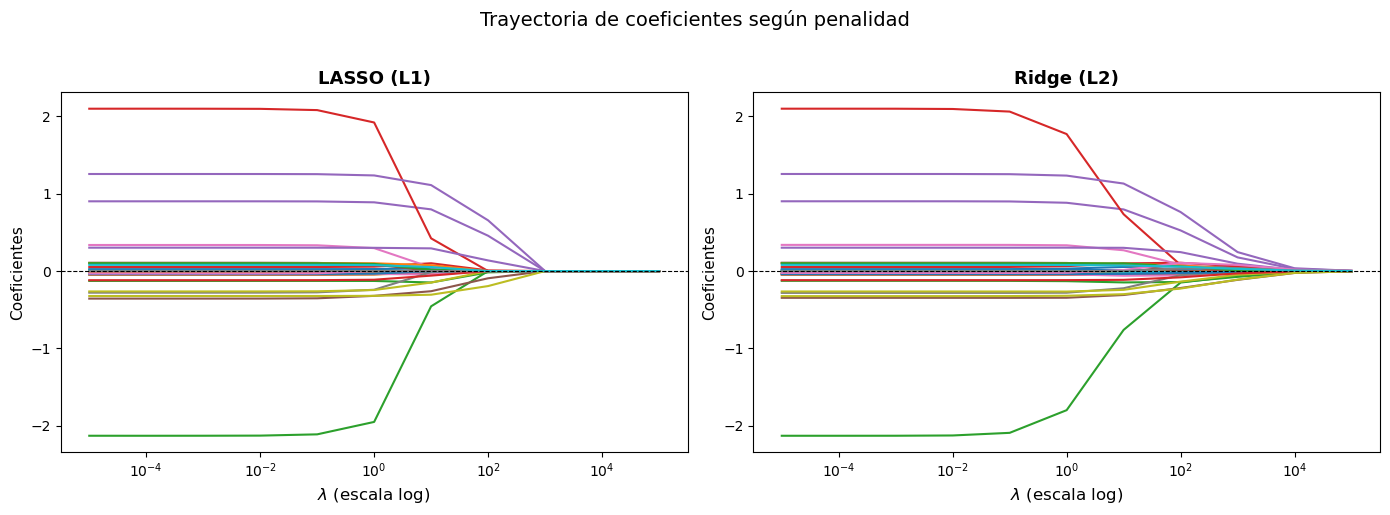

Guardado: A1_coeficientes.png


In [18]:
#  A.1 VISUALIZACIÓN DE COEFICIENTES RIDGE Y LASSO 

#Grid de lambdas = 10^n, n en {-5,...,5}
lambdas = 10**np.linspace(-5, 5, 11)

# Escalar X númericas
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

#loop
coefs_lasso = []
coefs_ridge = []

for lam in lambdas:
    C = 1 / lam 

    m_lasso = LogisticRegression(penalty='l1', C=C, solver='liblinear',
                                  fit_intercept=False, max_iter=1000)
    m_ridge = LogisticRegression(penalty='l2', C=C, solver='lbfgs',
                                  fit_intercept=False, max_iter=1000)
    m_lasso.fit(X_train_sc, y_train)
    m_ridge.fit(X_train_sc, y_train)

    coefs_lasso.append(m_lasso.coef_[0])
    coefs_ridge.append(m_ridge.coef_[0])

coefs_lasso = np.array(coefs_lasso)  # shape: (11, 48)
coefs_ridge = np.array(coefs_ridge)

# Graficamos 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, coefs, title in zip(
        axes,
        [coefs_lasso, coefs_ridge],
        ['LASSO (L1)', 'Ridge (L2)']):

    ax.plot(lambdas, coefs)          # una línea por variable
    ax.set_xscale("log")             # eje x en escala logarítmica
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(r'$\lambda$ (escala log)', fontsize=12)
    ax.set_ylabel('Coeficientes', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('tight')

plt.suptitle('Trayectoria de coeficientes según penalidad', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{RUTA}/A1_coeficientes.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: A1_coeficientes.png")

## 2. Penalidad óptima por Cross-validation y visualización

L1 → λ_cv = 10^-5 = 0.00001
L2 → λ_cv = 10^-2 = 0.01000


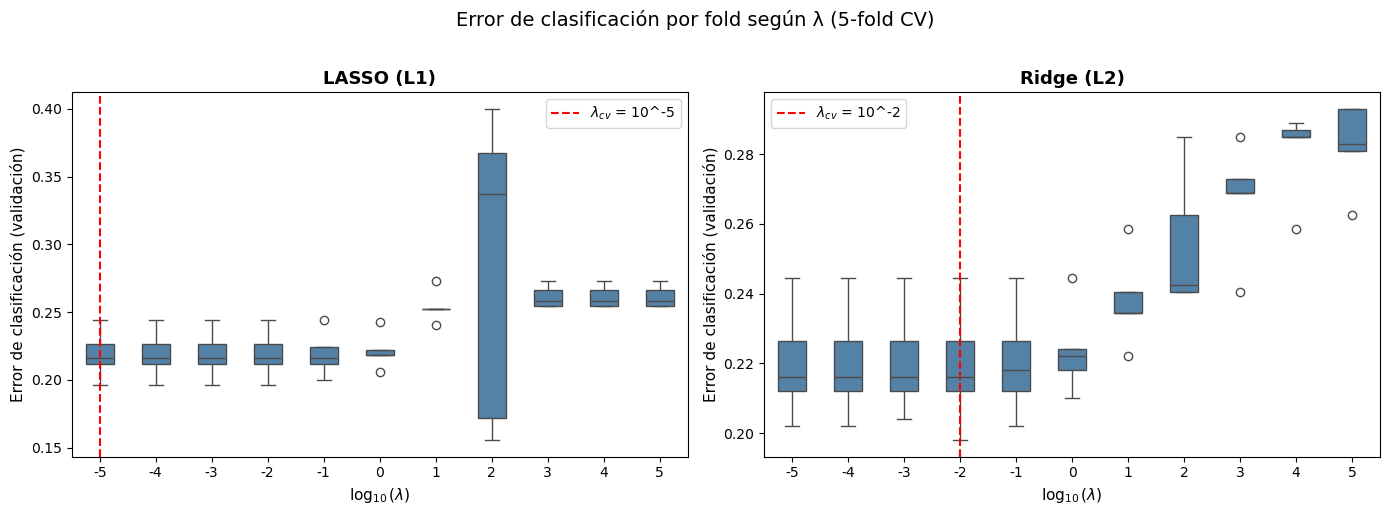

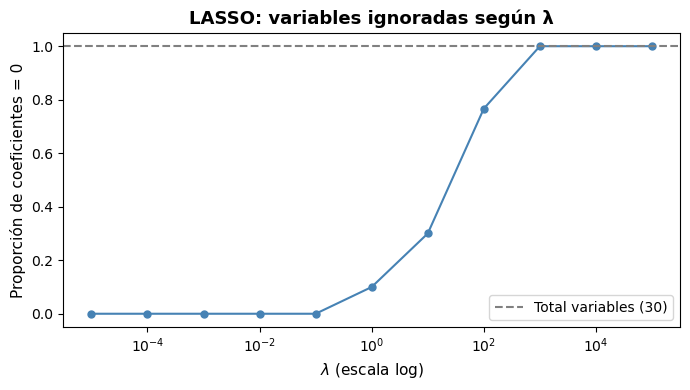

Guardados: A2_boxplots_cv.png | A2_lasso_zeros.png


In [19]:
# A.2 PENALIDAD ÓPTIMA POR CV

kf = KFold(n_splits=5, shuffle=True, random_state=100)

# ── Loop: lambda × fold → error de clasificación ──────────────────────────────
resultados = pd.DataFrame(columns=["lambda", "particion", "error"])

for lam in lambdas:
    C = 1 / lam
    for i, (train_idx, val_idx) in enumerate(kf.split(X_train_sc)):
        X_fold_tr, X_fold_val = X_train_sc[train_idx], X_train_sc[val_idx]
        y_fold_tr, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        for penalty, solver in [('l1', 'liblinear'), ('l2', 'lbfgs')]:
            m = LogisticRegression(penalty=penalty, C=C, solver=solver,
                                    fit_intercept=False, max_iter=1000)
            m.fit(X_fold_tr, y_fold_tr)
            error = 1 - m.score(X_fold_val, y_fold_val)

            df_i = pd.DataFrame({
                "lambda":    [lam],
                "particion": [i],
                "penalty":   [penalty],
                "error":     [error]
            })
            resultados = pd.concat([resultados, df_i], ignore_index=True)

resultados["log_lambda"] = np.log10(resultados["lambda"].astype(float)).round(0).astype(int)

# λ óptimo: menor error promedio por penalidad 
for penalty in ['l1', 'l2']:
    sub = resultados[resultados['penalty'] == penalty]
    avg = sub.groupby('log_lambda')['error'].mean()
    lam_opt_log = avg.idxmin()
    lam_opt     = 10**float(lam_opt_log)   # ← este cambio
    print(f"{penalty.upper()} → λ_cv = 10^{lam_opt_log} = {lam_opt:.5f}")

#Box-plots (estilo Tutorial 7 con seaborn) 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (penalty, title) in zip(axes, [('l1', 'LASSO (L1)'), ('l2', 'Ridge (L2)')]):
    sub = resultados[resultados['penalty'] == penalty]

    # λ óptimo para marcar
    avg      = sub.groupby('log_lambda')['error'].mean()
    opt_log  = avg.idxmin()

    sns.boxplot(data=sub, x='log_lambda', y='error', ax=ax,
                color='steelblue', width=0.5)

    # Línea vertical en λ óptimo
    xticks = sorted(sub['log_lambda'].unique())
    opt_pos = xticks.index(opt_log)
    ax.axvline(x=opt_pos, color='red', linestyle='--', linewidth=1.5,
               label=fr'$\lambda_{{cv}}$ = 10^{opt_log}')

    ax.set_xlabel(r'$\log_{10}(\lambda)$', fontsize=11)
    ax.set_ylabel('Error de clasificación (validación)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

plt.suptitle('Error de clasificación por fold según λ (5-fold CV)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{RUTA}/A2_boxplots_cv.png", dpi=150, bbox_inches='tight')
plt.show()

# Parte Opcional: proporción de coeficientes = 0 en LASSO (estilo Tutorial 9) 
alphas_list, num_cero = [], []

for lam in lambdas:
    m = LogisticRegression(penalty='l1', C=1/lam, solver='liblinear',
                            fit_intercept=False, max_iter=1000)
    m.fit(X_train_sc, y_train)
    count = np.sum(np.isclose(m.coef_[0], 0, atol=1e-8))
    alphas_list.append(lam)
    num_cero.append(count / X_train.shape[1])  # proporción

fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(alphas_list, num_cero, marker='o', linestyle='-', color='steelblue', markersize=5)
ax2.set_xscale('log')
ax2.axhline(y=1, color='grey', linestyle='--', label=f'Total variables ({X_train.shape[1]})')
ax2.set_xlabel(r'$\lambda$ (escala log)', fontsize=11)
ax2.set_ylabel('Proporción de coeficientes = 0', fontsize=11)
ax2.set_title('LASSO: variables ignoradas según λ', fontsize=13, fontweight='bold')
ax2.set_ylim(-0.05, 1.05)
ax2.legend()
plt.tight_layout()
plt.savefig(f"{RUTA}/A2_lasso_zeros.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardados: A2_boxplots_cv.png | A2_lasso_zeros.png")

## 3. Estimación con Lambda de Cross-Validation y comparación de coeficientes

In [20]:
# ── A.3 ESTIMACIÓN FINAL Y TABLA COMPARATIVA (estilo Tutorial 9) ──────────────

# Lambdas óptimas del CV
lam_cv_lasso = 10**(-2)   # de A.2
lam_cv_ridge = 10**(-1)   # de A.2

# ── Estimar los tres modelos sobre X_train completo ───────────────────────────

# Sin penalidad (C muy grande ≈ sin regularización)
m_logit = LogisticRegression(penalty='l2', C=1e10, solver='lbfgs',
                              fit_intercept=False, max_iter=1000)

# LASSO con λ_cv
m_lasso = LogisticRegression(penalty='l1', C=1/lam_cv_lasso, solver='liblinear',
                              fit_intercept=False, max_iter=1000)

# Ridge con λ_cv
m_ridge = LogisticRegression(penalty='l2', C=1/lam_cv_ridge, solver='lbfgs',
                              fit_intercept=False, max_iter=1000)

m_logit.fit(X_train_sc, y_train)
m_lasso.fit(X_train_sc, y_train)
m_ridge.fit(X_train_sc, y_train)

# ── Tabla de coeficientes ──────────────────────────────────────────────────────
df_coef = pd.DataFrame({
    'Variable':      X_train.columns,
    'Logit_sin_pen': m_logit.coef_[0],
    'LASSO_L1':      m_lasso.coef_[0],
    'Ridge_L2':      m_ridge.coef_[0],
})

# Filas de MSE → acá usamos error de clasificación en test
errores = pd.DataFrame({
    'Variable':      ['Error_test'],
    'Logit_sin_pen': [1 - m_logit.score(X_test_sc, y_test)],
    'LASSO_L1':      [1 - m_lasso.score(X_test_sc, y_test)],
    'Ridge_L2':      [1 - m_ridge.score(X_test_sc, y_test)],
})

df_comp = pd.concat([df_coef, errores], ignore_index=True).round(4)

# Variables que LASSO lleva a cero
vars_cero = df_coef.loc[np.isclose(df_coef['LASSO_L1'], 0, atol=1e-8), 'Variable'].tolist()
print(f"Variables con coef LASSO = 0 ({len(vars_cero)}):")
print(vars_cero)
print()

print(df_comp.to_string(index=False))

# Exportar
df_comp.to_csv(f"{RUTA}/A3_tabla_coeficientes.csv", index=False)
print("\nGuardado: A3_tabla_coeficientes.csv")

Variables con coef LASSO = 0 (0):
[]

  Variable  Logit_sin_pen  LASSO_L1  Ridge_L2
      CH03         0.0241    0.0243    0.0249
      CH04        -0.0472   -0.0475   -0.0473
      CH06        -2.1285   -2.1257   -2.0907
      CH07         0.0520    0.0519    0.0533
      CH08         0.9020    0.9009    0.8998
      CH09        -0.0449   -0.0448   -0.0448
      CH10        -0.0358   -0.0361   -0.0365
      CH11        -0.0400   -0.0399   -0.0399
      CH12         0.0091    0.0100    0.0091
      CH13         0.0061    0.0052    0.0059
      CH15         0.0175    0.0172    0.0172
      CH16        -0.0196   -0.0195   -0.0194
  NIVEL_ED        -0.1259   -0.1272   -0.1266
     edad2         2.0986    2.0956    2.0611
  CAT_OCUP         1.2548    1.2536    1.2522
   INTENSI         0.1077    0.1071    0.1077
     PP03C         0.3385    0.3365    0.3383
     PP03D        -0.2817   -0.2786   -0.2817
  PP3E_TOT        -0.2637   -0.2630   -0.2640
  PP3F_TOT         0.0026    0.0019    0.0

# Parte B: Herramientas de IA y reflexión final

Realizado en documento de LaTeX. 